# Stochastic Graph Neural Network (SGNN)

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import optax
from torx import DiscretePCircuit, draw_circuit, PISING, StateVectorSimulator
from tqdm import tqdm

In [2]:
NUM_NODES = 8
G = nx.gnp_random_graph(NUM_NODES, 0.5, 2)
EDGES = list(G.edges())
NUM_EDGES = len(EDGES)

num_states = 2**NUM_NODES
states_01 = np.array(
    [
        [(i >> (NUM_NODES - 1 - j)) & 1 for j in range(NUM_NODES)]
        for i in range(num_states)
    ]
)
spins = 2 * states_01 - 1


def cut_value(bitstring):
    return sum(1 for i, j in EDGES if bitstring[i] != bitstring[j])


cut_values = np.array([cut_value(s) for s in states_01])
MAXCUT = int(cut_values.max())
optimal_states = np.where(cut_values == MAXCUT)[0]

print(f"Graph: {NUM_NODES} nodes, {NUM_EDGES} edges")
print(f"MaxCut = {MAXCUT}")
for idx in optimal_states:
    label = "".join(str(b) for b in states_01[idx])
    print(f"{label}")

Graph: 8 nodes, 13 edges
MaxCut = 12
01011000
10100111


In [3]:
gates = []
for i, j in EDGES:
    gates.append(PISING(theta=jnp.array([-1.0, 0.0, 0.0, 1.0, 0.5]), sites=[i, j]))

circuit = DiscretePCircuit(gates, reps=20)
draw_circuit(DiscretePCircuit(gates))

     ┌────────┐┌────────┐                                                                                                                
p_0: ┤        ├┤        ├────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     │        ││        │                                                                                                                
     │        ││        │┌────────┐┌────────┐┌────────┐                                                                                  
p_1: ┤ PISING ├┤        ├┤ PISING ├┤        ├┤        ├──────────────────────────────────────────────────────────────────────────────────
     │        ││        ││        ││        ││        │                                                                                  
     │        ││        ││        ││        ││        │┌────────┐                                                                        
p_2: ┤        ├┤ PISING ├┤        

## Training

We maximize the expected cut size under the circuit's output distribution:

$$\mathcal{L} = -\mathbb{E}_\rho[\text{cut}] = -\sum_{(i,j) \in \mathcal{E}} \frac{1 - \langle s_i s_j \rangle}{2}$$

In [4]:
sim = StateVectorSimulator()
sv_init = jnp.zeros(num_states).at[0].set(1.0)

sisj = np.zeros((NUM_EDGES, num_states))
for e, (i, j) in enumerate(EDGES):
    sisj[e] = spins[:, i] * spins[:, j]
sisj = jnp.array(sisj)

cut_values_jnp = jnp.array(cut_values, dtype=jnp.float32)
template_compiled = StateVectorSimulator.build_circuit(circuit)


def forward(params):
    J_params = params[:NUM_EDGES]
    beta = jax.nn.softplus(params[NUM_EDGES])
    dt = jax.nn.softplus(params[NUM_EDGES + 1])

    new_gates = list(template_compiled.gates)
    for e, (i, j) in enumerate(EDGES):
        new_gates[e] = eqx.tree_at(
            lambda g: g.theta,
            new_gates[e],
            jnp.array([J_params[e], 0.0, 0.0, beta, dt]),
        )
    compiled = eqx.tree_at(lambda c: c.gates, template_compiled, new_gates)
    return sim.density(compiled, sv_init)


def loss_fn(params):
    dist = forward(params)
    correlations = sisj @ dist  # <s_i s_j> per edge
    expected_cut = jnp.sum((1.0 - correlations) / 2.0)
    return -expected_cut


@jax.jit
def train_step(params, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


key = jax.random.key(0)
params = jnp.concatenate(
    [
        jax.random.uniform(key, (NUM_EDGES,), minval=-1.5, maxval=-0.5),
        jnp.array([0.5, 0.1]),
    ]
)

epochs = 200
schedule = optax.cosine_decay_schedule(3e-2, epochs)
optimizer = optax.adam(schedule)
opt_state = optimizer.init(params)

In [5]:
loss_history = []

for step in tqdm(range(epochs)):
    params, opt_state, loss = train_step(params, opt_state)
    loss_history.append(loss)

    if step % 100 == 0:
        tqdm.write(f"Step {step:4d}  E[cut]={-loss:.2f}")

print(f"\nFinal:  E[cut]={-loss_history[-1]:.2f}  MaxCut={MAXCUT}")

  0%|          | 0/200 [00:00<?, ?it/s]E0331 03:27:23.732025 2600209 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0331 03:27:23.834752 2600213 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0331 03:27:23.941598 2600214 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
  1%|          | 2/200 [00:13<18:45,  5.68s/it]

Step    0  E[cut]=7.62


 51%|█████     | 102/200 [00:24<00:10,  9.61it/s]

Step  100  E[cut]=12.00


100%|██████████| 200/200 [00:34<00:00,  5.84it/s]


Final:  E[cut]=11.97  MaxCut=12


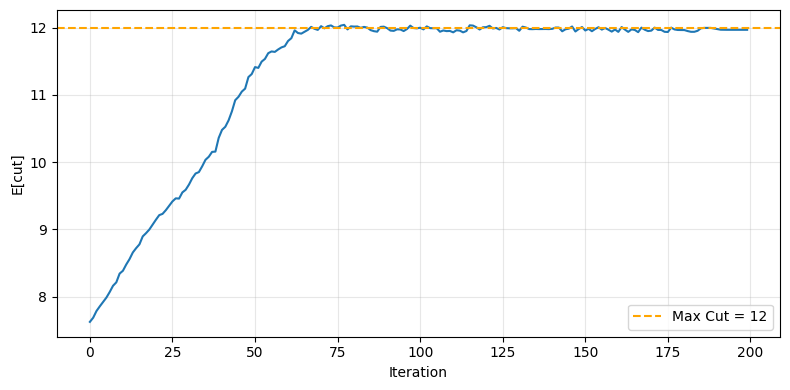

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot([-l for l in loss_history])
plt.axhline(MAXCUT, ls="--", color="orange", label=f"Max Cut = {MAXCUT}")
plt.xlabel("Iteration")
plt.ylabel("E[cut]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()